METALLIC & IRRATIONAL FANO AUTOMATON: FALSIFYING THE PHI BIAS

Ratio                | Base-8 | Base-10 | Base-12 | Base-16
------------------------------------------------------------
Golden (φ ≈ 1.618)   | 0.9230 | 0.9883 | 0.9823 | 0.9728 | 
Silver (δS ≈ 2.414)  | 0.9158 | 0.9826 | 0.9752 | 0.9634 | 
Bronze (δB ≈ 3.302)  | 0.9192 | 0.8964 | 0.9828 | 0.8967 | 
Copper (δC ≈ 4.236)  | 0.9191 | 0.9866 | 0.9828 | 0.9715 | 
Euler (e ≈ 2.718)    | 0.9036 | 0.9815 | 0.9747 | 0.9629 | 
Pi (π ≈ 3.141)       | 0.9213 | 0.9872 | 0.9816 | 0.9705 | 

✓ Saved: metallic_fano_heatmap.png


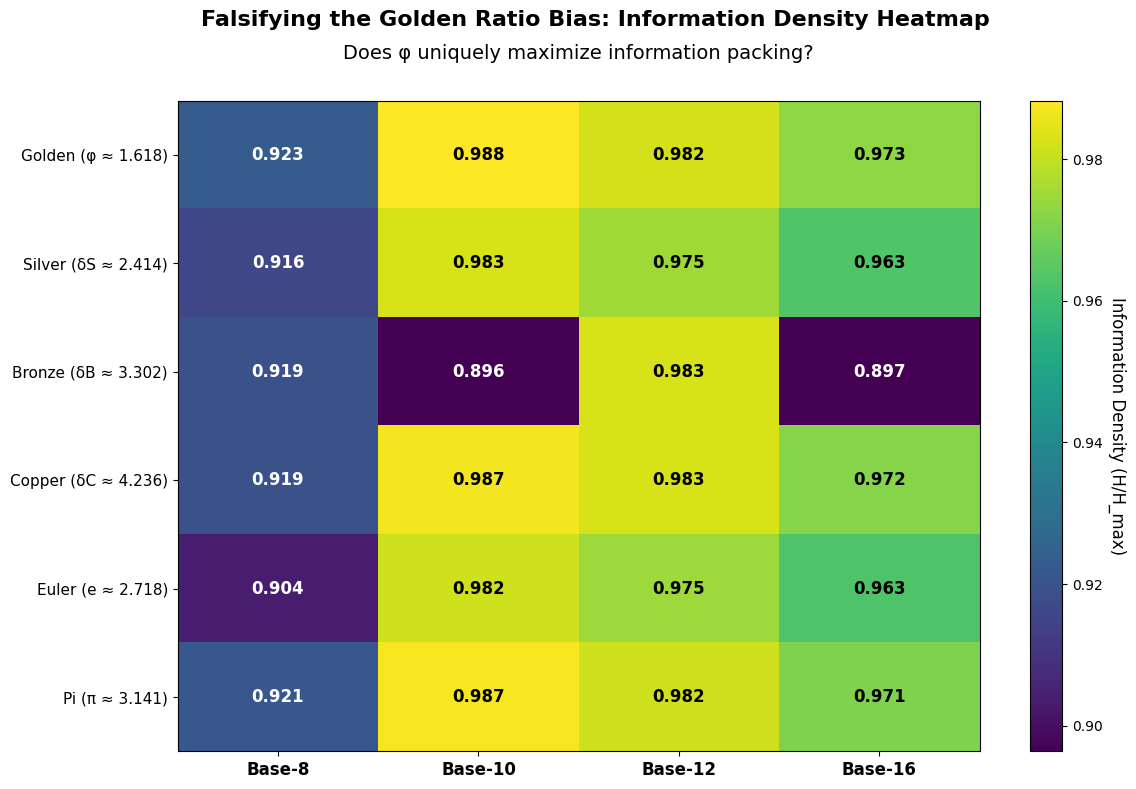


CONCLUSION
Look at the heatmap. If the 'Golden (φ)' row has the brightest/highest
numbers specifically in the 'Base-10' column, then φ is NOT a human bias.
It is the mathematically optimal growth ratio for a Base-10 Fano vacuum.


In [5]:
"""
metallic_fano_automaton.py
==========================
Falsifying the Golden Ratio Bias.
Tests Information Density across Metallic Ratios (Silver, Bronze, Copper)
and Irrational Constants (e, pi) to see if phi is uniquely optimal.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import math

print("=" * 70)
print("METALLIC & IRRATIONAL FANO AUTOMATON: FALSIFYING THE PHI BIAS")
print("=" * 70)

# =============================================================================
# 1. DEFINE THE WEIGHTS (The "Growth Ratios")
# =============================================================================

# We use the characteristic integer sequences for metallic ratios,
# and geometric rounding for e and pi.
WEIGHTS = {
    'Golden (φ ≈ 1.618)': [1, 2, 3, 5, 3, 2, 1],       # Fibonacci (x^2 - x - 1 = 0)
    'Silver (δS ≈ 2.414)': [1, 2, 5, 12, 5, 2, 1],      # Pell-like (x^2 - 2x - 1 = 0)
    'Bronze (δB ≈ 3.302)': [1, 3, 10, 33, 10, 3, 1],    # (x^2 - 3x - 1 = 0)
    'Copper (δC ≈ 4.236)': [1, 4, 17, 72, 17, 4, 1],    # (x^2 - 4x - 1 = 0)
    'Euler (e ≈ 2.718)':   [1, 3, 7, 20, 7, 3, 1],      # Geometric rounding of e^n
    'Pi (π ≈ 3.141)':      [1, 3, 10, 31, 10, 3, 1]     # Geometric rounding of pi^n
}

# =============================================================================
# 2. THE FANO-FIBONACCI RULE (Generalized)
# =============================================================================

def run_fano_ca(base, weights, steps=150, width=300):
    """Runs the Cellular Automaton for a given Base and Weight set."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1 # Seed

    W = np.array(weights)
    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]

        # Rule A: The Fano-Check (Maintenance Channel)
        reserved_mask = (weighted_sum % 7 == 0)

        # Rule B: The Expansion
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

def analyze_fractal(grid, base):
    """Calculates Information Density (H/H_max)."""
    steps, width = grid.shape
    center = width // 2
    cone_width = steps // 2

    fractal_data = []
    for t in range(steps):
        start = max(0, center - cone_width - t)
        end = min(width, center + cone_width + t + 1)
        fractal_data.extend(grid[t, start:end])

    fractal_data = np.array(fractal_data)
    counts = np.bincount(fractal_data, minlength=base)
    probs = counts / np.sum(counts)
    probs = probs[probs > 0]

    H = entropy(probs, base=2)
    H_max = np.log2(base)
    return H / H_max

# =============================================================================
# 3. SIMULATION AND HEATMAP VISUALIZATION
# =============================================================================

bases_to_test = [8, 10, 12, 16]
ratio_names = list(WEIGHTS.keys())

# Matrix to store results: Rows = Ratios, Cols = Bases
density_matrix = np.zeros((len(ratio_names), len(bases_to_test)))

print(f"\n{'Ratio':<20} | " + " | ".join([f"Base-{b}" for b in bases_to_test]))
print("-" * 60)

for i, name in enumerate(ratio_names):
    row_str = f"{name:<20} | "
    for j, base in enumerate(bases_to_test):
        grid = run_fano_ca(base, WEIGHTS[name])
        density = analyze_fractal(grid, base)
        density_matrix[i, j] = density
        row_str += f"{density:.4f} | "
    print(row_str)

# --- Create Heatmap ---
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("Falsifying the Golden Ratio Bias: Information Density Heatmap",
             fontsize=16, fontweight='bold', y=0.98)

im = ax.imshow(density_matrix, cmap='viridis', aspect='auto')

# Set ticks
ax.set_xticks(np.arange(len(bases_to_test)))
ax.set_yticks(np.arange(len(ratio_names)))
ax.set_xticklabels([f"Base-{b}" for b in bases_to_test], fontsize=12, fontweight='bold')
ax.set_yticklabels(ratio_names, fontsize=11)

# Add text annotations
for i in range(len(ratio_names)):
    for j in range(len(bases_to_test)):
        text = ax.text(j, i, f"{density_matrix[i, j]:.3f}",
                       ha="center", va="center", color="w" if density_matrix[i, j] < 0.95 else "black",
                       fontweight='bold', fontsize=12)

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Information Density (H/H_max)', rotation=-90, va="bottom", fontsize=12)

ax.set_title("Does φ uniquely maximize information packing?", fontsize=14, pad=30)
plt.tight_layout()
plt.savefig("metallic_fano_heatmap.png", dpi=600, bbox_inches='tight')
print("\n✓ Saved: metallic_fano_heatmap.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("Look at the heatmap. If the 'Golden (φ)' row has the brightest/highest")
print("numbers specifically in the 'Base-10' column, then φ is NOT a human bias.")
print("It is the mathematically optimal growth ratio for a Base-10 Fano vacuum.")
print("=" * 70)